In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vijayaadithyanvg/car-price-predictionused-cars/car data.csv


=== TASK 3: AUTO-DETECTED COLUMNS ===
Numerical Features: ['Year', 'Present_Price', 'Driven_kms', 'Owner']
Categorical Features: ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']

=== TASK 3 REGRESSION METRICS ===
R-squared (R²) Score: 0.9732
Mean Absolute Error (MAE): 0.46


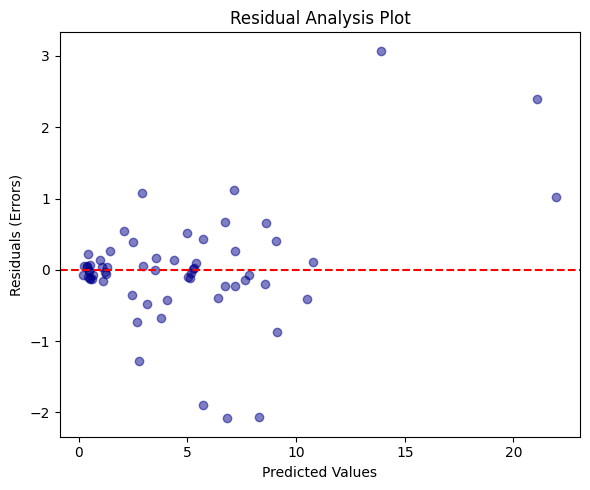

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load your local dataset
df = pd.read_csv('/kaggle/input/datasets/vijayaadithyanvg/car-price-predictionused-cars/car data.csv')
df.columns = df.columns.str.strip()

target_col = 'Selling_Price' 

# 2. Automated Feature Detection (Prevents KeyErrors)
X = df.drop(columns=[target_col], errors='ignore')
y = df[target_col]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("=== TASK 3: AUTO-DETECTED COLUMNS ===")
print(f"Numerical Features: {num_features}")
print(f"Categorical Features: {cat_features}\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Processing & Model Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42, n_estimators=100, max_depth=4))
])

# 4. Train & Evaluate
reg_pipeline.fit(X_train, y_train)
y_pred = reg_pipeline.predict(X_test)

print("=== TASK 3 REGRESSION METRICS ===")
print(f"R-squared (R²) Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")

# 5. Diagnostic Plot
plt.figure(figsize=(6, 5))
plt.scatter(y_pred, (y_test - y_pred), alpha=0.5, color='darkblue')
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Analysis Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Errors)")
plt.tight_layout()
plt.savefig("car_price_residuals.png")
plt.show()